# Scheduling Policy Comparisons

This notebook compares FCFS to non-FCFS scheduling strategies using the same two-class simulation model. The goal here is policy comparison, not the baseline simulation story.

Notation used here:

- `r` is residual delay in the state.
- `\tau` is the original offered delay used in the behavioral functions.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "appointment_simulation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for module_name in list(sys.modules):
    if module_name == "appointment_simulation" or module_name.startswith("appointment_simulation."):
        del sys.modules[module_name]

from IPython.display import display

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from appointment_simulation import (
    ClassWindowPolicy,
    FCFSPolicy,
    LatestAvailablePolicy,
    PatientClassConfig,
    ReservedCapacityPolicy,
    SimulationConfig,
    green_savin_no_show,
    simulate,
    simulate_replications,
    step_balking,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## Policy comparison setup

All scenarios below use the same patient classes and demand assumptions unless explicitly stated otherwise.

In [2]:
BASE_CONFIG = SimulationConfig(
    horizon_days=15,
    slots_per_day=25,
    burn_in_days=250,
    measure_days=1000,
    access_target_days=30,
    rng_seed=7,
)


def make_classes(lambda_1=0.14, lambda_2=0.10, balk_variant="baseline"):
    if balk_variant == "baseline":
        balk_1 = step_balking(threshold=4, low_delay_probability=0.05, high_delay_probability=0.60)
        balk_2 = step_balking(threshold=3, low_delay_probability=0.08, high_delay_probability=0.70)
    else:
        balk_1 = step_balking(threshold=2, low_delay_probability=0.10, high_delay_probability=0.85)
        balk_2 = step_balking(threshold=2, low_delay_probability=0.12, high_delay_probability=0.90)

    return [
        PatientClassConfig(
            class_id=1,
            label="class_1 (MRI-like)",
            arrival_rate=lambda_1,
            balk_probability=balk_1,
            cancel_probability=0.10,
            no_show_probability=green_savin_no_show(gamma_0=0.01, gamma_max=0.31, sensitivity=50.0),
        ),
        PatientClassConfig(
            class_id=2,
            label="class_2 (mental-health-like)",
            arrival_rate=lambda_2,
            balk_probability=balk_2,
            cancel_probability=0.06,
            no_show_probability=green_savin_no_show(gamma_0=0.15, gamma_max=0.51, sensitivity=9.0),
        ),
    ]

BASE_CLASSES = make_classes()


## Policy comparison

The notebook compares FCFS to latest-available placement, reserved-capacity protection, class-specific windows, and a stricter balking scenario.

In [3]:
comparison_rows = []
comparison_setups = [
    ("FCFS baseline", FCFSPolicy(), make_classes()),
    ("Latest-slot policy", LatestAvailablePolicy(), make_classes()),
    (
        "Reserved-capacity policy",
        ReservedCapacityPolicy.from_shares(
            slots_per_day=BASE_CONFIG.slots_per_day,
            reserved_share_by_class={1: 0.20, 2: 0.20},
        ),
        make_classes(),
    ),
    ("Class-window policy", ClassWindowPolicy(max_delay_by_class={1: 4, 2: 8}), make_classes()),
    ("Stricter step balking", FCFSPolicy(), make_classes(balk_variant="strict")),
]

for name, policy, classes in comparison_setups:
    result = simulate(classes, config=BASE_CONFIG, policy=policy)
    comparison_rows.append(
        {
            "setup": name,
            "policy": result.policy_name,
            "aggregate_mean_delay": result.summary_aggregate["mean_delay_booked"],
            "booked_within_access_target_per_arrival": result.summary_aggregate[
                "booked_within_access_target_per_arrival"
            ],
            "served_per_booked": result.summary_aggregate["served_per_booked"],
            "booked_slot_utilization": result.slot_summary_aggregate["booked_slot_utilization"],
            "attended_slot_utilization": result.slot_summary_aggregate["attended_slot_utilization"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values("setup")
comparison_df

,setup,policy,aggregate_mean_delay,booked_within_access_target_per_arrival,served_per_booked,booked_slot_utilization,attended_slot_utilization
3,Class-window policy,ClassWindowPolicy,0.040995,0.938350,0.926602,0.22268,0.20704
0,FCFS baseline,FCFSPolicy,0.040995,0.938350,0.926602,0.22268,0.20704
1,Latest-slot policy,LatestAvailablePolicy,14.000000,0.353703,0.718310,0.07816,0.06148
2,Reserved-capacity policy,ReservedCapacityPolicy,0.244271,0.940518,0.917214,0.22068,0.20648
4,Stricter step balking,FCFSPolicy,0.045737,0.888907,0.934124,0.21192,0.19852


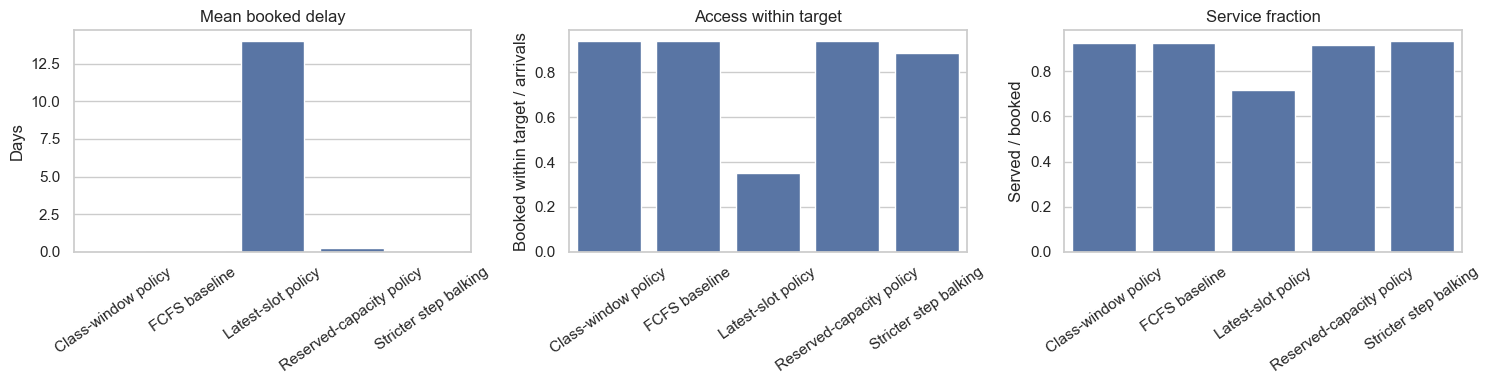

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=comparison_df, x="setup", y="aggregate_mean_delay", ax=axes[0])
axes[0].set_title("Mean booked delay")
axes[0].set_xlabel("")
axes[0].set_ylabel("Days")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=comparison_df, x="setup", y="booked_within_access_target_per_arrival", ax=axes[1])
axes[1].set_title("Access within target")
axes[1].set_xlabel("")
axes[1].set_ylabel("Booked within target / arrivals")
axes[1].tick_params(axis="x", rotation=35)

sns.barplot(data=comparison_df, x="setup", y="served_per_booked", ax=axes[2])
axes[2].set_title("Service fraction")
axes[2].set_xlabel("")
axes[2].set_ylabel("Served / booked")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()

In [5]:
class_rows = []
for name, policy, classes in comparison_setups:
    result = simulate(classes, config=BASE_CONFIG, policy=policy)
    frame = result.summary_by_class[["class_id", "label", "mean_delay_booked", "booked_within_access_target_per_arrival", "served_per_booked"]].copy()
    frame["setup"] = name
    class_rows.append(frame)

pd.concat(class_rows, ignore_index=True).sort_values(["setup", "class_id"])


,class_id,label,mean_delay_booked,booked_within_access_target_per_arrival,served_per_booked,setup
6,1,class_1 (MRI-like),0.040413,0.952257,0.982072,Class-window policy
7,2,class_2 (mental-health-like),0.041830,0.919103,0.847059,Class-window policy
0,1,class_1 (MRI-like),0.040413,0.952257,0.982072,FCFS baseline
1,2,class_2 (mental-health-like),0.041830,0.919103,0.847059,FCFS baseline
2,1,class_1 (MRI-like),14.000000,0.388666,0.822533,Latest-slot policy
3,2,class_2 (mental-health-like),14.000000,0.305380,0.534974,Latest-slot policy
4,1,class_1 (MRI-like),0.245112,0.952474,0.967027,Reserved-capacity policy
5,2,class_2 (mental-health-like),0.242961,0.922497,0.839691,Reserved-capacity policy
8,1,class_1 (MRI-like),0.043437,0.896878,0.986266,Stricter step balking
9,2,class_2 (mental-health-like),0.049038,0.877715,0.859303,Stricter step balking
